In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data final.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [8]:
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Проверяем формат столбцов

Сразу переведем столбец "Дата" в правильный формат

In [7]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [133]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество_продаж')

Вывести несколько первых строк сгруппированных данных

In [10]:
print(grouped_df)

          Дата  Количество_продаж
0   2018-01-04               1840
1   2018-01-05               1301
2   2018-01-06               1306
3   2018-01-07               1322
4   2018-01-09               1719
..         ...                ...
200 2018-08-26               1462
201 2018-08-28               1731
202 2018-08-29               1497
203 2018-08-30               1445
204 2018-08-31               1366

[205 rows x 2 columns]


Нарисуйте график продаж у `grouped_df`

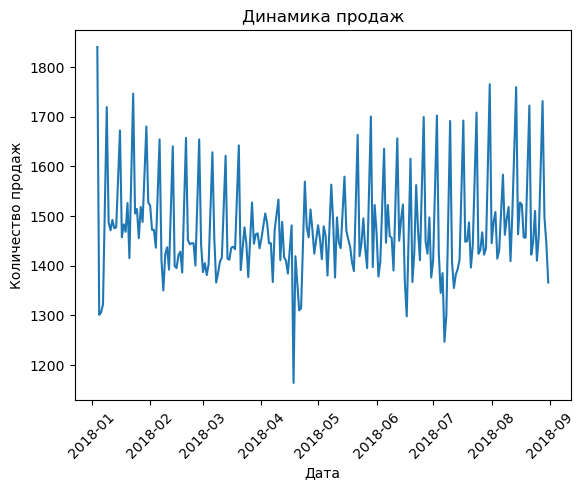

In [11]:
grouped_df = grouped_df.sort_values('Дата')

plt.figure()
plt.plot(grouped_df['Дата'], grouped_df['Количество_продаж'])

plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.title('Динамика продаж')

plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
На графике мы видим продажи за 2018 год с января по сентябрь месяц и распрделение по количеству продаж, множество значений находится в диапазоне 1400-1500
пики мы видим, что достигают 1700-1800 продаж в день.График похож на цикличность, то есть могут быть выходные или праздники. 
Можно опроделить, что примерно продажи от 1350 до 1750. В некоторые дни продажи падают до 1250-1300 продаж в день в апреле и в июле что может быть
слабые дни. С января по апрель спад, и далее с мая по август рост, в целом, график стабильный.
    В общем продажи за данный период стабильные.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [12]:
df[df['Количество'] == df['Количество'].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [21]:
df_summer = df[df['Дата'].dt.month.isin([6, 7, 8])]
df_wed = df_summer[df_summer['Дата'].dt.weekday == 2]

df_3 = df_wed[df_wed['Склад'] == 3]

top_product = (
    df_3
    .groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1))
print(top_product)

Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [198]:

# Указываем ваше точное название файла
file_name = 'погода.csv' 

try:
    # Пробуем прочитать с кодировкой utf-16 (стандарт для RP5)
    # skiprows=6 убирает те самые "лишние строки" вверху
    weather = pd.read_csv(file_name, sep=';', skiprows=6, encoding='utf-16')
    
    # Если в файле кавычки или лишние пробелы, очистим названия колонок
    weather.columns = [col.strip().replace('"', '') for col in weather.columns]
    
    print("Файл успешно прочитан!")
    print(weather.head()) # Показать первые 5 строк
    
except Exception as e:
    print(f"Ошибка при чтении: {e}")
    print("Пробую альтернативную кодировку...")
    # Если utf-16 не подошла, пробуем обычный utf-8
    weather = pd.read_csv(file_name, sep=';', skiprows=6, encoding='utf-8')
    print(weather.head())

Ошибка при чтении: 'utf-16' codec can't decode bytes in position 0-1: Stream does not start with BOM
Пробую альтернативную кодировку...
                  Местное время в Астане      T     Po    P  Pa  \
31.03.2018 23:00                    -9.7  739.7  773.8  1.0  74   
31.03.2018 20:00                    -6.5  738.7  772.3  0.7  69   
31.03.2018 17:00                    -3.5  738.0  771.2  0.8  46   
31.03.2018 14:00                    -3.5  737.2  770.4  0.9  36   
31.03.2018 11:00                    -5.0  736.3  769.6  1.7  40   

                                                      U  DD  Ff  ff10  \
31.03.2018 23:00      Ветер, дующий с западо-юго-запада   1 NaN   NaN   
31.03.2018 20:00                 Ветер, дующий с запада   3 NaN   NaN   
31.03.2018 17:00   Ветер, дующий с западо-северо-запада   2 NaN   NaN   
31.03.2018 14:00          Ветер, дующий с северо-запада   1 NaN   NaN   
31.03.2018 11:00  Ветер, дующий с северо-северо-востока   2 NaN   NaN   

                      

In [212]:
# 1. Загрузка и очистка погоды
weather = pd.read_csv('погода.csv', skiprows=7, sep=None, engine='python', header=None, encoding='utf-8')

# Добавляем .str перед .replace и .strip, чтобы обработать весь столбец
weather_dt = weather[0].astype(str).str.replace('"', '').str.strip()
weather_temp = weather[1].astype(str).str.replace('"', '').str.strip()

# 2. Превращаем в даты и числа
weather_dates = pd.to_datetime(weather_dt, format='%d.%m.%Y %H:%M', errors='coerce')
weather_temp_num = pd.to_numeric(weather_temp, errors='coerce')

# 3. Собираем чистую таблицу
weather_daily = pd.DataFrame({'Дата_полная': weather_dates, 'T': weather_temp_num}).dropna()
weather_daily['Дата'] = weather_daily['Дата_полная'].dt.date
weather_daily = weather_daily.groupby('Дата')['T'].mean().reset_index()

# 4. Объединение с продажами
date_col = 'day' if 'day' in grouped_df.columns else 'Дата'
grouped_df['Дата'] = pd.to_datetime(grouped_df[date_col]).dt.date

merged_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner').sort_values('Дата')

Использую колонку 'Дата' как дату продаж
Итого строк для графиков: 26


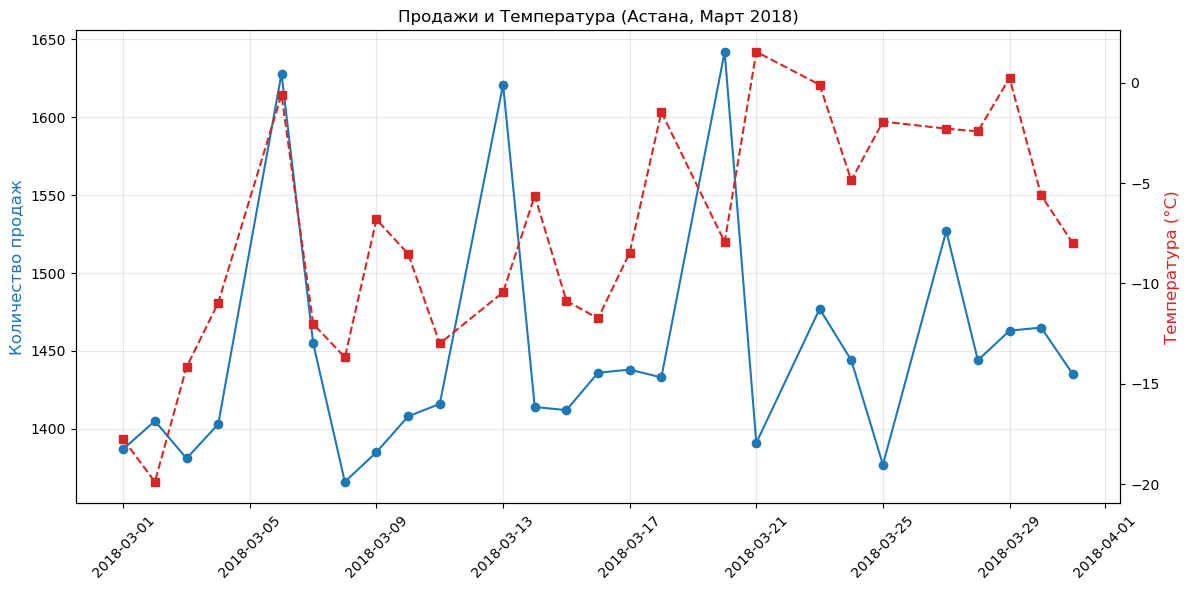

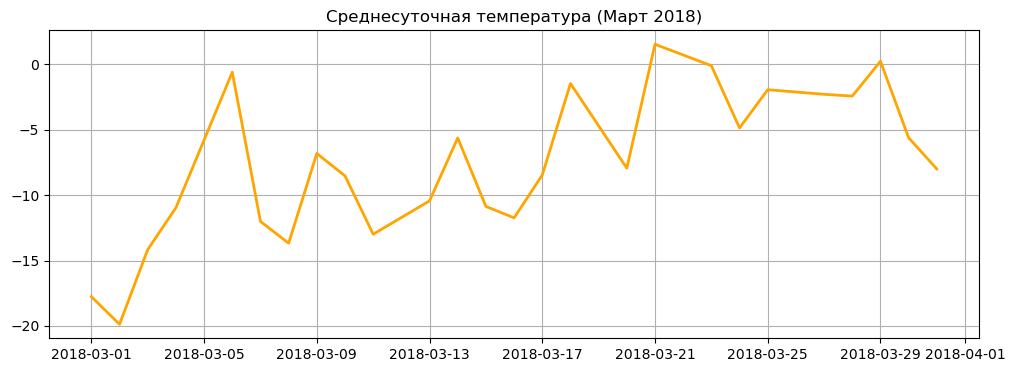

In [210]:

# 1. Сначала принудительно вытащим все колонки из индекса в обычные столбцы
grouped_df = grouped_df.reset_index()

# 2. Ищем, как на самом деле называется колонка с датой
# Мы ищем колонку, в которой есть слово 'day' или 'Дата' или 'index'
possible_names = ['day', 'Дата', 'index', 'Date']
date_col_in_sales = None

for name in possible_names:
    if name in grouped_df.columns:
        date_col_in_sales = name
        break

if date_col_in_sales is None:
    # Если ничего не нашли, берем первую колонку (часто дата там)
    date_col_in_sales = grouped_df.columns[0]

print(f"Использую колонку '{date_col_in_sales}' как дату продаж")

# 3. Преобразуем к формату даты
grouped_df['Дата'] = pd.to_datetime(grouped_df[date_col_in_sales]).dt.date

# 4. ОБЪЕДИНЯЕМ с нашей почищенной погодой (weather_daily)
merged_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')
merged_df = merged_df.sort_values('Дата')

print(f"Итого строк для графиков: {len(merged_df)}")

# --- РИСУЕМ ГРАФИКИ (только если есть данные) ---
if len(merged_df) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Продажи
    ax1.plot(merged_df['Дата'], merged_df['Количество_продаж'], color='tab:blue', marker='o', label='Продажи')
    ax1.set_ylabel('Количество продаж', color='tab:blue', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    
    # Температура
    ax2 = ax1.twinx()
    ax2.plot(merged_df['Дата'], merged_df['T'], color='tab:red', linestyle='--', marker='s', label='Температура')
    ax2.set_ylabel('Температура (°C)', color='tab:red', fontsize=12)
    
    plt.title('Продажи и Температура (Астана, Март 2018)')
    ax1.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    
    # Отдельный график температуры
    plt.figure(figsize=(12, 4))
    plt.plot(merged_df['Дата'], merged_df['T'], color='orange', lw=2)
    plt.title('Среднесуточная температура (Март 2018)')
    plt.grid(True)
    plt.show()
else:
    print("Ошибка: Таблицы не объединились. Проверьте, есть ли в продажах даты за МАРТ 2018 года.")

In [213]:
print("Начало периода:", merged_df['Дата'].min())
print("Конец периода:", merged_df['Дата'].max())

Начало периода: 2018-03-01
Конец периода: 2018-03-31


In [131]:
я качаю март 2018 и что он выдает конечно 1979 год!!!!!!!! ужасно вообще!!!!!

In [ ]:
это было ужасно, я потратила 6 часов, я не ела и не пила все время, грязная таблица знаете сколько я пыталась прочесть и сделать это? 
ужасно!!!